# Setup python environment

In [1]:
%pip install pandas numpy matplotlib tensorflow scikit-learn ai_edge_litert

Note: you may need to restart the kernel to use updated packages.


In [166]:
import numpy as np
import tensorflow as tf
import random
import os

# Set the seed for reproducibility
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)


# Constants

In [299]:
FEATURE_COLS = ["temperature", "pressure", "humidity", "gas_resistance"]
FEATURE_COLS_EXTENDED = FEATURE_COLS + [f"{c}_diff" for c in FEATURE_COLS]
TARGET_COL = "label"
SEQ_LEN = 10

CLASSES = [
    "cinnamon",
    "basil",
    "turmeric",
    "thyme",
    "setup_air"
]

TO_BE_CORRECTED = [
    "cinnamon",
    "basil",
    "turmeric",
    "thyme",
]

SAMPLE_TYPES = ["sample", "baseline"]

NUM_CLASSES = len(CLASSES)

SAVE_PATH = "../models/cnn/"
MODEL_NAME = "background_new"

# Load Data

In [311]:
import os
import pandas as pd

def add_fotd_features(df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    df = df.copy()
    
    # Ensure correct order
    df = df.sort_values(["id", "position"])
    
    for col in feature_cols:
        df[col + "_diff"] = df.groupby("id")[col].diff()
    
    df = df.fillna(0)
    return df


def load_dataset(base_dir: str, sample_types: list) -> pd.DataFrame:
    dfs = []
    i = 0
    for folder in os.listdir(base_dir):
        if folder not in CLASSES:
            continue

        folder_path = os.path.join(base_dir, folder)
        if not os.path.isdir(folder_path):
            continue

        for file in os.listdir(folder_path):
            if not file.endswith(".csv"):
                continue

            has_desired_type = False
            for st in sample_types:
                if st in os.path.basename(file):
                    has_desired_type = True
                    break
            if not has_desired_type: continue


            file_path = os.path.join(folder_path, file)
            df = pd.read_csv(file_path)
            df['id'] = df.apply(lambda x: f"{i}_{x['sensor_index']}_{x['fingerprint_index']}", axis=1)
            i += 1
            dfs.append(df)

    if len(dfs) == 0:
        raise ValueError(f"No CSVs found under {base_dir}")
    return pd.concat(dfs, ignore_index=True)

# data = load_dataset("../data/dataset/new", SAMPLE_TYPES)
# data = add_fotd_features(data, FEATURE_COLS)
data = pd.read_csv("../data/dataset/new/setup.csv")
data['id'] = data.apply(lambda x: f"{x['sensor_index']}_{x['fingerprint_index']}", axis=1)
print(len(data["id"].unique()), " fingerprints loaded.")
data

275  fingerprints loaded.


,sensor_index,fingerprint_index,position,plate_temperature,heater_duration,temperature,pressure,humidity,gas_resistance,label,id
0,1,0,0,100,150,28.82,1029.83,37.13,281783,setup_air,1_0
1,2,0,0,100,150,28.17,1106.85,47.13,157976,setup_air,2_0
2,1,0,1,200,150,28.92,1029.83,37.12,40201,setup_air,1_0
3,2,0,1,200,150,28.27,1106.85,47.16,25005,setup_air,2_0
4,5,0,0,320,8,30.91,1112.25,41.95,9538,setup_air,5_0
...,...,...,...,...,...,...,...,...,...,...,...
1111,5,11,0,320,8,36.92,1112.67,32.34,161565,setup_air,5_11
1112,2,95,0,100,150,31.14,1106.98,41.59,4424521,setup_air,2_95
1113,1,93,0,100,150,31.65,1029.95,32.18,4967860,setup_air,1_93
1114,3,17,9,320,150,30.29,1034.12,43.20,65878,setup_air,3_17


In [312]:
data = data[data["sensor_index"].isin([7, 8])]

In [313]:
len(data)

98

In [266]:
data[FEATURE_COLS].mean()

temperature       3.560085e+01
pressure          1.111251e+03
humidity          3.502617e+01
gas_resistance    1.038519e+06
dtype: float64

In [241]:
def fractional_baseline_correction(df: pd.DataFrame, feature_names: list, baseline: pd.Series, epsilon: float = 1e-6) -> pd.DataFrame:
    for feat in feature_names:
        df[feat] = df[feat].apply(lambda x: (x - baseline[feat]) / (baseline[feat] + epsilon))
    return df

data_corrected = data.copy()
dfs = []
baseline_dfs = []
# TEMPERATURES = list(data["plate_temperature"].unique())
for t in range(SEQ_LEN):
    for cls in TO_BE_CORRECTED:
        baseline_label = cls + "_baseline"
        baseline_df = data_corrected[data_corrected["position"] == t]
        baseline_df = baseline_df[baseline_df[TARGET_COL] == baseline_label]
        baseline = baseline_df[FEATURE_COLS_EXTENDED].mean()
        baseline_dfs.append(fractional_baseline_correction(baseline_df, FEATURE_COLS_EXTENDED, baseline))
        df = data_corrected[data_corrected["position"] == t]
        df = df[df[TARGET_COL] == cls]
        df = fractional_baseline_correction(df, FEATURE_COLS_EXTENDED, baseline)
        dfs.append(df)
print(len(dfs))
data_corrected = pd.concat(dfs)
baseline_dfs = pd.concat(baseline_dfs)
baseline_dfs[TARGET_COL] = "air"

# Copy into data for convenience
data = pd.concat([data_corrected.copy(), baseline_dfs.copy()])

40


In [242]:
data

,sensor_index,fingerprint_index,position,plate_temperature,heater_duration,temperature,pressure,humidity,gas_resistance,label,id,temperature_diff,pressure_diff,humidity_diff,gas_resistance_diff
3930,3,1,0,320,150,-0.060257,-0.033317,0.121194,-0.794412,cinnamon,3_3_1,0.000000,0.000000,0.000000,0.000000
4495,3,10,0,320,150,-0.000458,-0.033270,0.020644,0.340540,cinnamon,3_3_10,0.000000,0.000000,0.000000,0.000000
4554,3,11,0,320,150,0.003217,-0.033289,0.013546,0.380674,cinnamon,3_3_11,0.000000,0.000000,0.000000,0.000000
4622,3,12,0,320,150,0.006891,-0.033270,0.009051,0.394082,cinnamon,3_3_12,0.000000,0.000000,0.000000,0.000000
4685,3,13,0,320,150,0.010566,-0.033270,0.002900,0.435412,cinnamon,3_3_13,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5895,4,5,9,320,150,-0.021446,0.032707,-0.017398,-0.094561,air,4_4_5,0.087998,-0.999739,0.469146,-0.269807
5962,4,6,9,320,150,-0.017846,0.032773,-0.021273,-0.049766,air,4_4_6,0.087998,-0.999739,-0.160497,-0.198192
6023,4,7,9,320,150,-0.014573,0.032782,-0.025389,-0.020078,air,4_4_7,-0.183995,-0.999739,-0.580259,-0.185803
6081,4,8,9,320,150,-0.011301,0.032792,-0.028779,0.000764,air,4_4_8,-0.183995,1.614962,-1.000021,-0.229316


Drop incomplete fingerprints.

In [314]:
complete_ids = []
grouped = data.groupby("id")
for group in grouped:
    seq_len = len(group[1])
    if seq_len == SEQ_LEN:
        complete_ids.append(group[0])

data = data[data["id"].isin(complete_ids)]
print("Number of complete fingerprints per class: ")
for cls in CLASSES:
    print(
        f"{cls+' '*(max(map(len, CLASSES)) - len(cls))}\t{len(data[data[TARGET_COL] == cls]["id"].unique())}"
    )

Number of complete fingerprints per class: 
cinnamon 	0
basil    	0
turmeric 	0
thyme    	0
setup_air	0


## Split Data

This has to happen at this stage to prevent data leakage.

For the final version that gets exported, use all the available data, but we need train-test split for in-place evaluation.

In [244]:
TEST_RATIO = 0.3
train_data_ids = np.random.choice(complete_ids, size=int(len(complete_ids)*(1 - TEST_RATIO)), replace=False)
train_data = data[data["id"].isin(train_data_ids)]
test_data = data[data["id"].isin([i for i in complete_ids if i not in train_data_ids])]

print("Number of training fingerprints: ",len(train_data["id"].unique()))
print("Number of testing fingerprints: ", len(test_data["id"].unique()))

Number of training fingerprints:  158
Number of testing fingerprints:  69


# Neural Network

## Data preprocessing

In [245]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- Encode labels ---
label_encoder = LabelEncoder()
train_data['label_enc'] = label_encoder.fit_transform(train_data[TARGET_COL])
test_data['label_enc'] = label_encoder.transform(test_data[TARGET_COL])

# # --- Copy datasets ---
# train_data_scaled = train_data.copy()
# test_data_scaled = test_data.copy()

# # --- Helper for training scaling ---
# def scale_group(series: pd.Series) -> pd.Series:
#     scaler = StandardScaler()
#     return pd.Series(
#         scaler.fit_transform(series.values.reshape(-1, 1)).flatten(),
#         index=series.index
#     )

# # --- Scale TRAIN data (fit scalers per plate_temperature) ---
# scaling_stats = {}

# for feat in FEATURE_COLS_EXTENDED:
#     # Scale training data per temperature
#     train_data_scaled[feat] = train_data.groupby('plate_temperature')[feat].transform(scale_group)

#     # Store stats for test scaling
#     means = train_data.groupby('plate_temperature')[feat].mean()
#     stds  = train_data.groupby('plate_temperature')[feat].std().replace(0, 1.0)

#     scaling_stats[feat] = {
#         "mean": means,
#         "std": stds,
#     }

# # --- Apply SAME scaling to TEST data ---
# for feat in FEATURE_COLS_EXTENDED:
#     means = scaling_stats[feat]["mean"]
#     stds  = scaling_stats[feat]["std"]

#     # Map each row's plate_temperature → mean/std from TRAIN
#     test_means = test_data_scaled["plate_temperature"].map(means)
#     test_stds  = test_data_scaled["plate_temperature"].map(stds)

#     # Handle unseen temperatures (fallback to global stats)
#     global_mean = train_data[feat].mean()
#     global_std  = train_data[feat].std() or 1.0

#     test_means = test_means.fillna(global_mean)
#     test_stds  = test_stds.fillna(global_std).replace(0, 1.0)

#     # Apply scaling
#     test_data_scaled[feat] = (test_data_scaled[feat] - test_means) / test_stds

In [246]:
label_encoder.classes_

array(['air', 'basil', 'cinnamon', 'thyme', 'turmeric'], dtype=object)

In [247]:
train_data

,sensor_index,fingerprint_index,position,plate_temperature,heater_duration,temperature,pressure,humidity,gas_resistance,label,id,temperature_diff,pressure_diff,humidity_diff,gas_resistance_diff,label_enc
3930,3,1,0,320,150,-0.060257,-0.033317,0.121194,-0.794412,cinnamon,3_3_1,0.000000,0.000000,0.000000,0.000000,2
4495,3,10,0,320,150,-0.000458,-0.033270,0.020644,0.340540,cinnamon,3_3_10,0.000000,0.000000,0.000000,0.000000,2
4685,3,13,0,320,150,0.010566,-0.033270,0.002900,0.435412,cinnamon,3_3_13,0.000000,0.000000,0.000000,0.000000,2
4872,3,16,0,320,150,0.020588,-0.033242,-0.010822,0.478981,cinnamon,3_3_16,0.000000,0.000000,0.000000,0.000000,2
4994,3,18,0,320,150,0.026936,-0.033260,-0.019576,0.494372,cinnamon,3_3_18,0.000000,0.000000,0.000000,0.000000,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6390,4,13,9,320,150,0.003099,0.032820,-0.044276,0.105607,air,4_4_13,-0.183995,1.614962,-1.419783,-0.064935,0
5777,4,3,9,320,150,-0.030283,0.032726,-0.004565,-0.225683,air,4_4_3,0.087998,1.614962,-0.370378,-0.126880,0
5895,4,5,9,320,150,-0.021446,0.032707,-0.017398,-0.094561,air,4_4_5,0.087998,-0.999739,0.469146,-0.269807,0
6023,4,7,9,320,150,-0.014573,0.032782,-0.025389,-0.020078,air,4_4_7,-0.183995,-0.999739,-0.580259,-0.185803,0


In [250]:
from matplotlib import pyplot as plt

# for t in range(SEQ_LEN):
#     for cls in CLASSES:
#         xs = train_data[train_data[TARGET_COL] == cls]
#         xs = xs[xs["position"] == t]
#         xs = xs[xs["sensor_index"].isin([3, 4])]
#         xs = xs.sort_values(by="fingerprint_index")
#         for feat in ["gas_resistance"]:
#             plt.scatter(xs["fingerprint_index"], xs[feat], s=0.3, alpha=0.5, c=xs["sensor_index"])
#         plt.title(f"{cls} features over time")
#         plt.show()


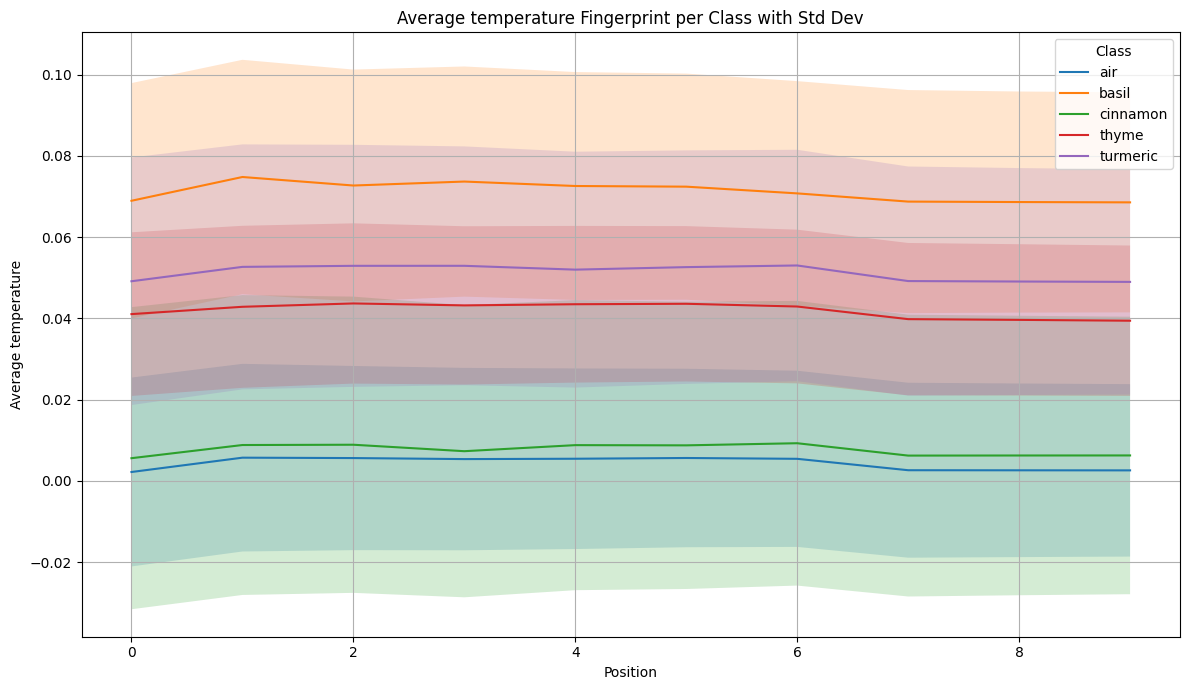

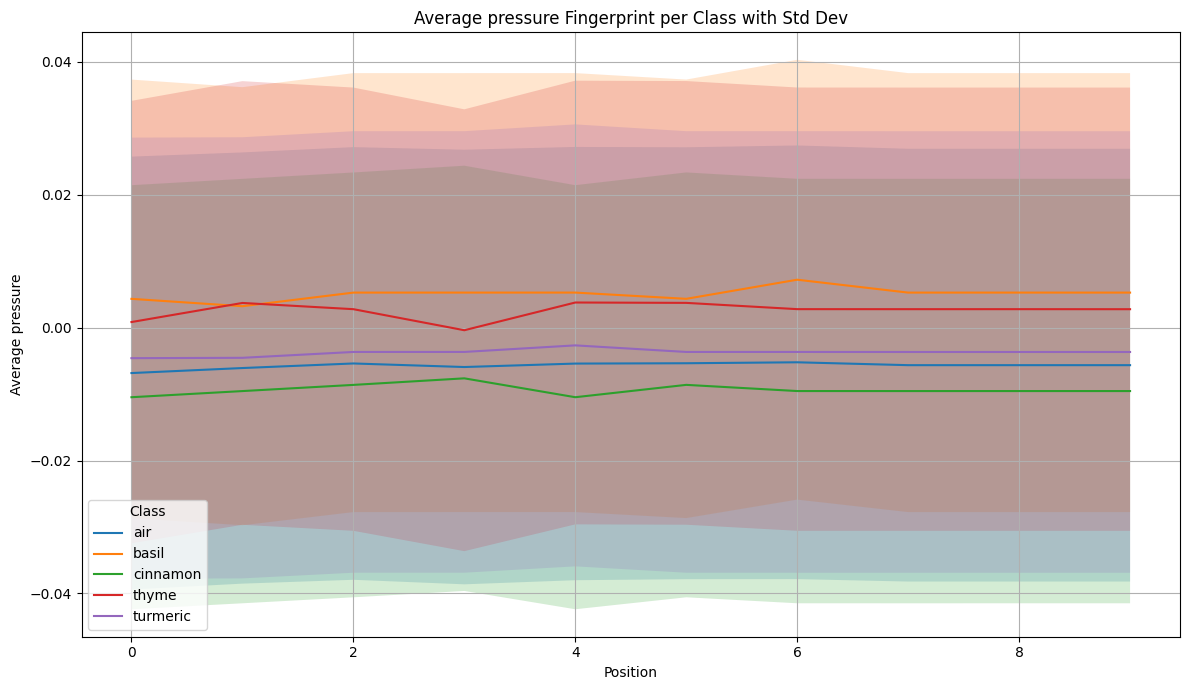

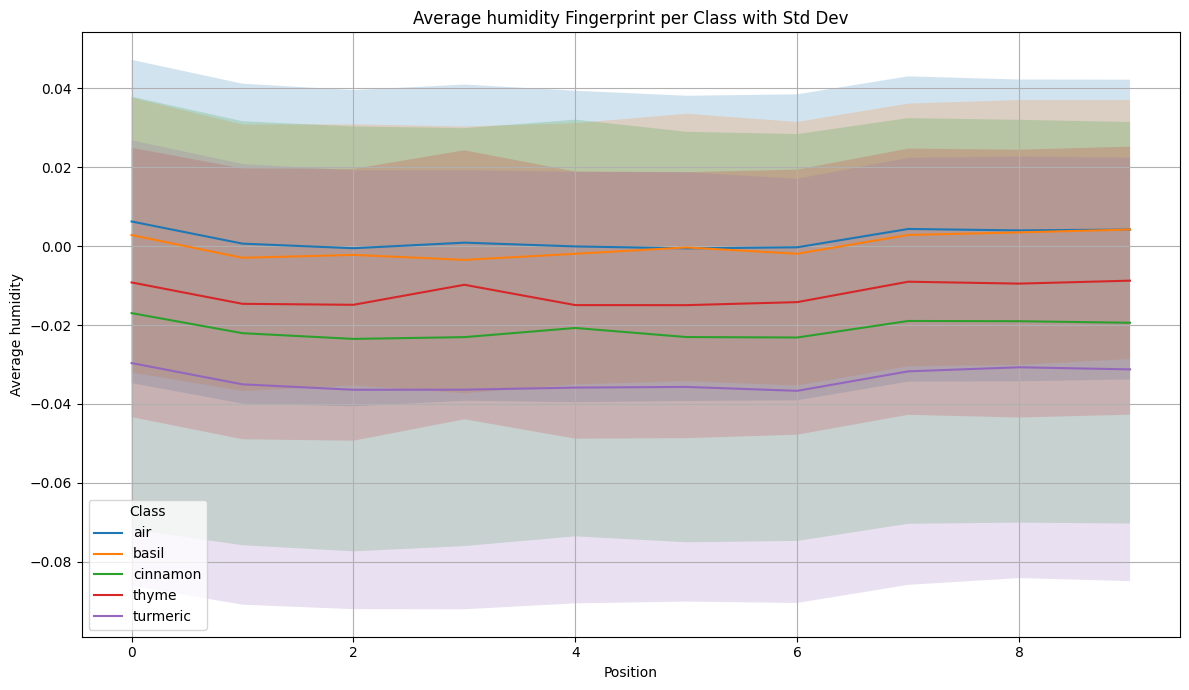

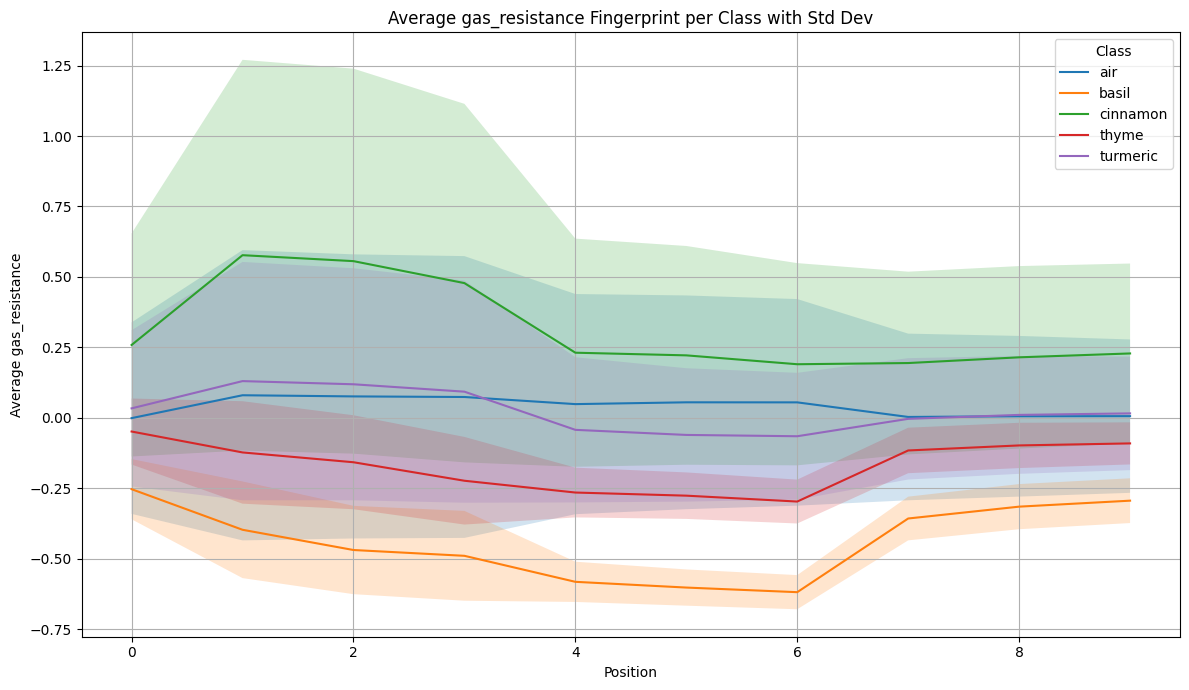

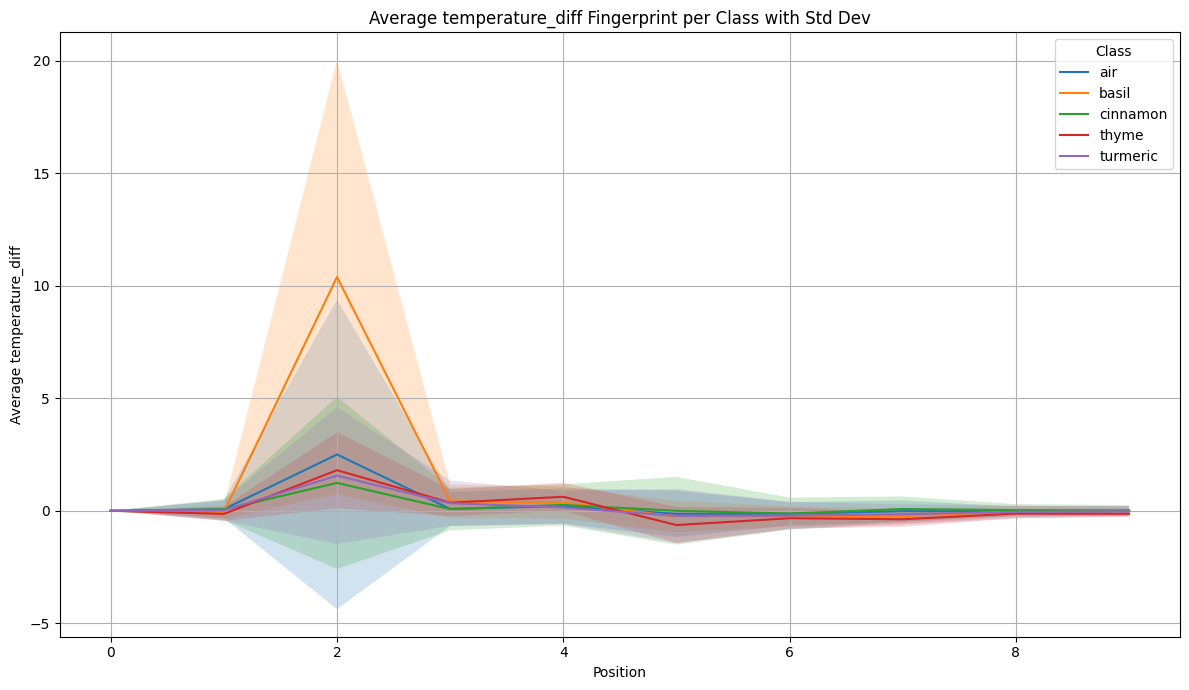

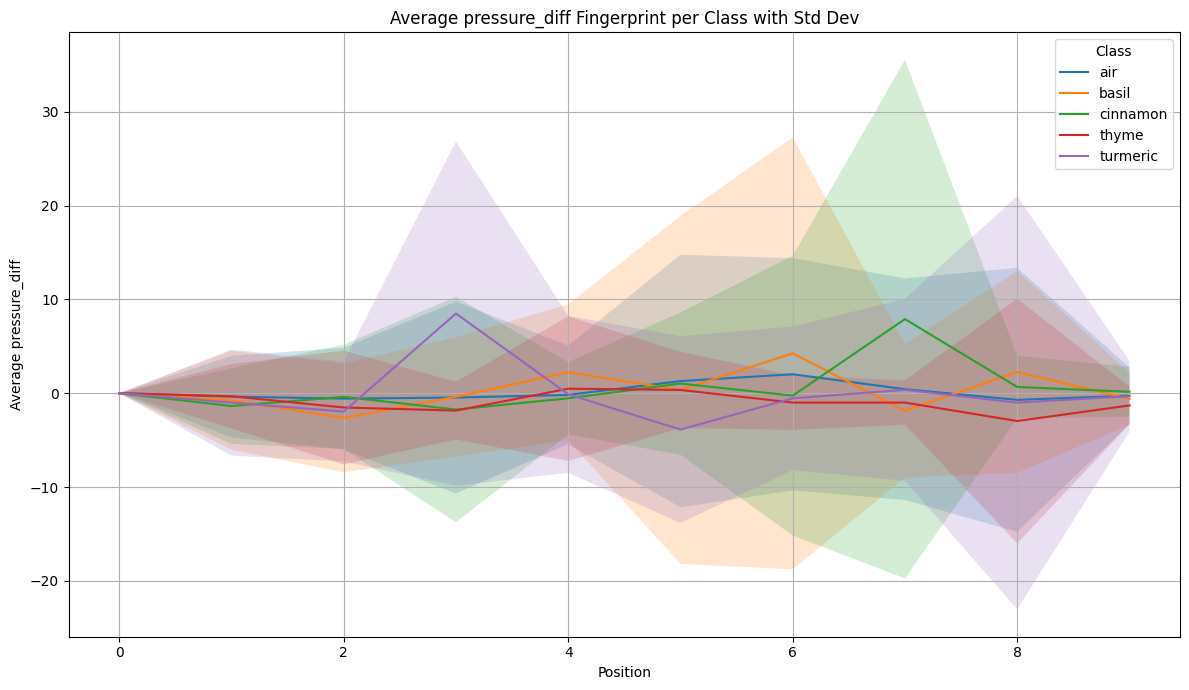

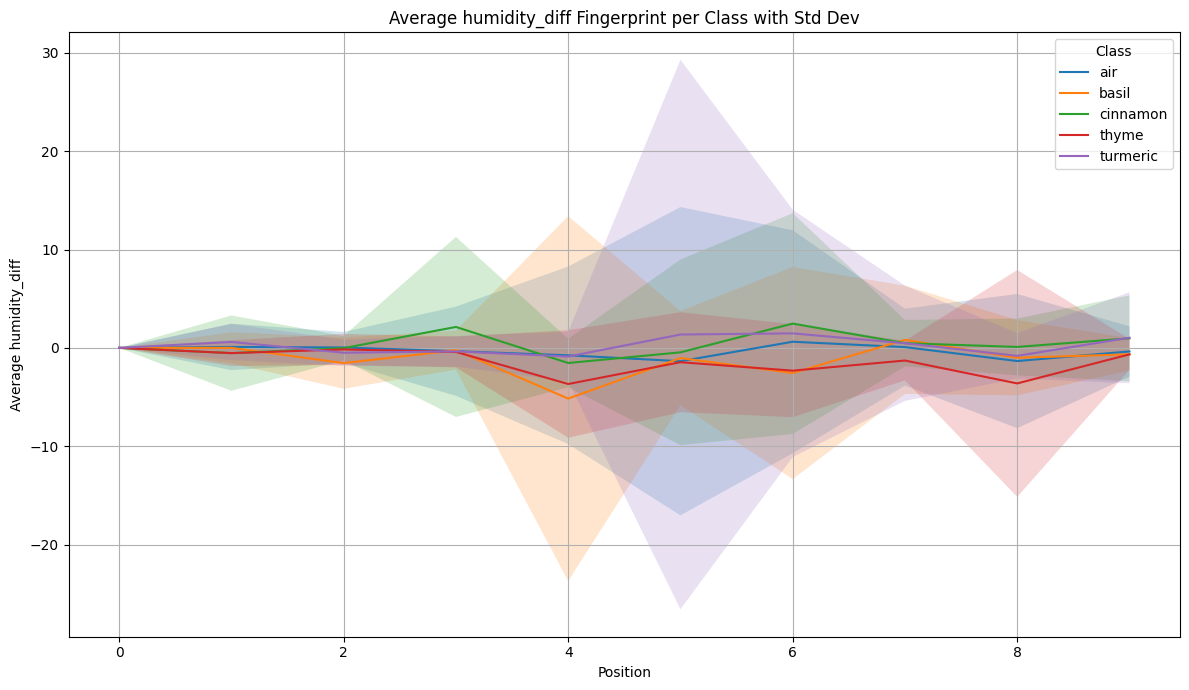

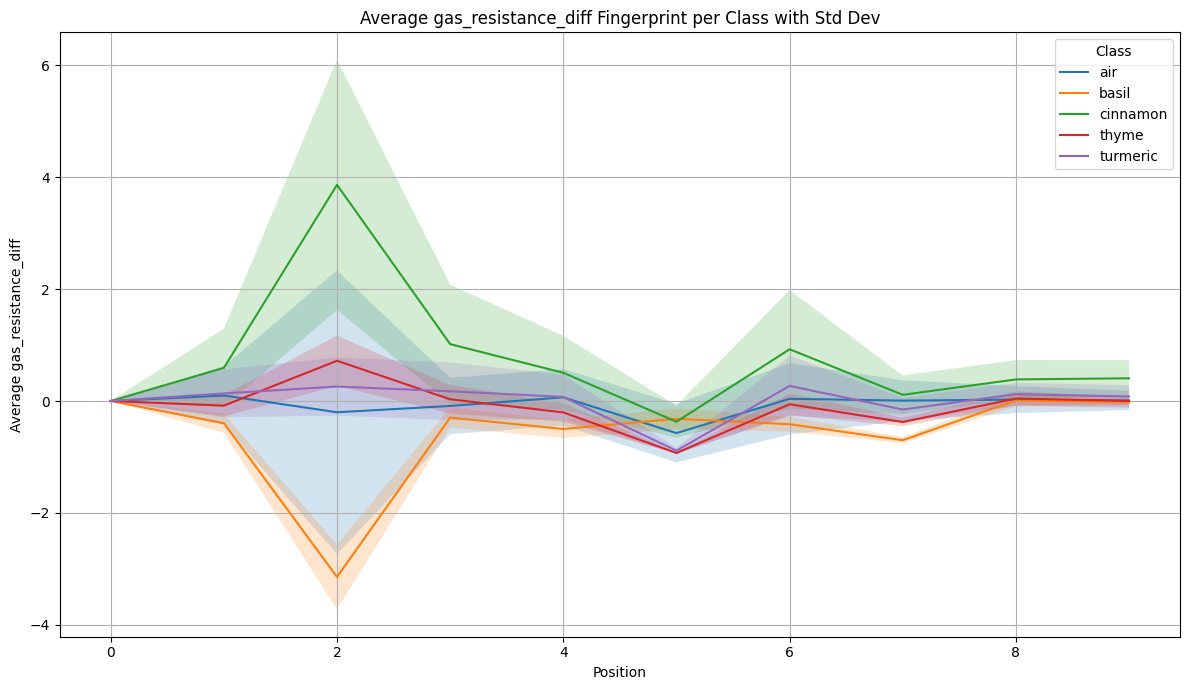

In [251]:
import matplotlib.pyplot as plt

# for feat in FEATURE_COLS_EXTENDED:
#     # Calculate mean and standard deviation of scaled_gas_resistance grouped by label and position
#     fingerprint_stats = train_data.groupby(['label', 'position'])[feat].agg(['mean', 'std']).reset_index()
#     fingerprint_stats.rename(columns={'mean': f'avg_scaled_{feat}', 'std': f'std_scaled_{feat}'}, inplace=True)

#     # Get unique labels to iterate through
#     classes = fingerprint_stats['label'].unique()

#     plt.figure(figsize=(12, 7))

#     # Plot each class's fingerprint
#     for cls in classes:
#         class_data = fingerprint_stats[fingerprint_stats['label'] == cls]
#         plt.errorbar(x=class_data['position'],
#                     y=class_data[f'avg_scaled_{feat}'],
#                     yerr=class_data[f'std_scaled_{feat}'],
#                     label=cls,
#                     capsize=4) # Add caps to the error bars

#     plt.xlabel('Position')
#     plt.ylabel(f'Average Scaled {feat}')
#     plt.title(f'Average {feat} Fingerprint per Class with Standard Deviation')
#     plt.legend(title='Class')
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()

def plot_fingerprint_stats(df: pd.DataFrame,
                            feature_cols: list[str],
                            target_col: str = "label",
                            pos_col: str = "position"):
    for feat in feature_cols:

        stats = (
            df.groupby([target_col, pos_col])[feat]
                .agg(["mean", "std"])
                .reset_index()
        )
        stats.rename(
            columns={"mean": f"avg_{feat}", "std": f"std_{feat}"},
            inplace=True,
        )

        classes = stats[target_col].unique()
        plt.figure(figsize=(12, 7))

        for cls in classes:
            cls_df = stats[stats[target_col] == cls]
            x = cls_df[pos_col]
            y = cls_df[f"avg_{feat}"]
            ystd = cls_df[f"std_{feat}"]

            plt.plot(x, y, label=cls)
            plt.fill_between(x, y - ystd, y + ystd, alpha=0.2)

        plt.xlabel(pos_col.capitalize())
        plt.ylabel(f"Average {feat}")
        plt.title(f"Average {feat} Fingerprint per Class with Std Dev")
        plt.legend(title="Class")
        plt.grid(True)
        plt.tight_layout()
        plt.show()


# call the helper with the training dataframe
plot_fingerprint_stats(train_data, FEATURE_COLS_EXTENDED)

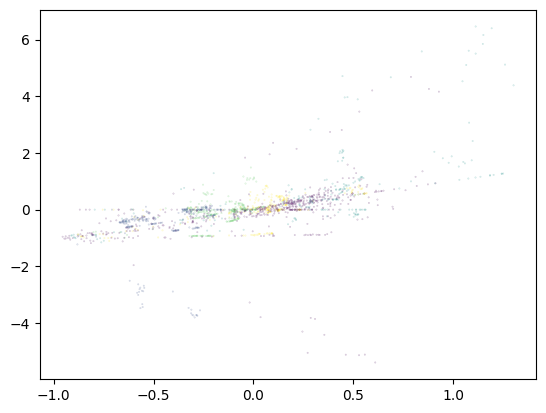

In [252]:
plt.scatter(train_data[FEATURE_COLS_EXTENDED[3]], train_data[FEATURE_COLS_EXTENDED[7]], s=0.1, alpha=0.3, c=train_data["label_enc"])
plt.show()

### PCA

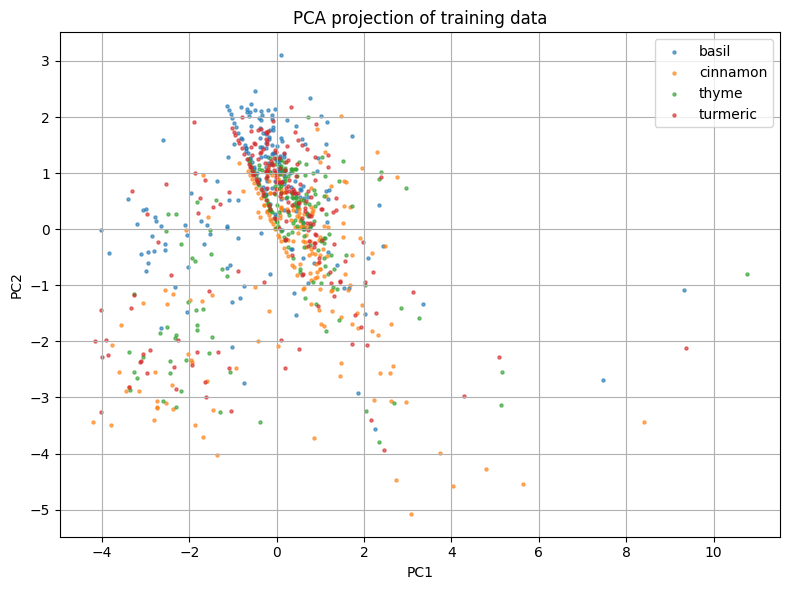

In [ ]:
from sklearn.decomposition import PCA

def plot_pca(df: pd.DataFrame,
             feature_cols: list[str],
             target_col: str = TARGET_COL) -> tuple[PCA, np.ndarray]:
    """
    run PCA on the given dataframe (features are scaled) and scatter
    the first two principal components, colouring points by `target_col`.

    returns the fitted PCA instance and the 2‑d transformed array.
    """
    # scale before PCA so that each feature contributes equally
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[feature_cols])

    pca = PCA(n_components=2, random_state=SEED)
    components = pca.fit_transform(X_scaled)

    plt.figure(figsize=(8, 6))
    for cls in df[target_col].unique():
        mask = df[target_col] == cls
        plt.scatter(components[mask, 0],
                    components[mask, 1],
                    label=cls,
                    alpha=0.6, s=5)

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA projection of training data")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return pca, components

# apply to the training dataset
pca_model, X_train_pca = plot_pca(train_data, FEATURE_COLS_EXTENDED)

### Export Train Data

In [134]:
model_dir = os.path.join(SAVE_PATH, MODEL_NAME)
if not os.path.isdir(model_dir): os.mkdir(model_dir)
train_data.to_csv(os.path.join(model_dir, "train_data.csv"))

### Create Sequences

In [135]:
import numpy as np

def create_sequences_grouped(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
    seq_len: int
):
    X, y = [], []
    grouped = df.groupby("id")
    num_skipped = 0
    for _id, group in grouped:
        group = group.sort_values("position")
        data = group[feature_cols].values

        if len(data) == seq_len:
            X.append(data)
            y.append(int(group[target_col].iloc[0]))
        else:
            num_skipped += 1
    print("Number of sequences skipped: ", num_skipped)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)


X_train_seq, y_train_seq = create_sequences_grouped(train_data, FEATURE_COLS_EXTENDED, 'label_enc', SEQ_LEN)
X_test_seq, y_test_seq = create_sequences_grouped(test_data, FEATURE_COLS_EXTENDED, 'label_enc', SEQ_LEN)

Number of sequences skipped:  0
Number of sequences skipped:  0


## Build model

In [136]:
from keras.models import Sequential
from keras.layers import Conv1D, Dense, Dropout, Input, GlobalAveragePooling1D

model = Sequential([
    Input(shape=(SEQ_LEN, len(FEATURE_COLS_EXTENDED))),

    Conv1D(16, kernel_size=3, activation='relu'),
    Conv1D(16, kernel_size=3, activation='relu'),

    GlobalAveragePooling1D(),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 8, 16)          │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 6, 16)          │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,572 (6.14 KB)

 Trainable params: 1,572 (6.14 KB)

 Non-trainable params: 0 (0.00 B)

In [144]:
(X_test_seq[:, :, 1] == 0.0).sum()

np.int64(1876)

## Train model

In [137]:
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split


early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


X_train_seq, X_val_seq, y_train_seq, y_val_seq = train_test_split(
    X_train_seq,
    y_train_seq,
    test_size=0.1,
    stratify=y_train_seq,
    random_state=42
)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=200,
    batch_size=64,
    callbacks=[early_stop],
    shuffle=True
)

Epoch 1/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3719 - loss: 1.3040 - val_accuracy: 0.4064 - val_loss: 1.2221
Epoch 2/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4067 - loss: 1.1972 - val_accuracy: 0.4041 - val_loss: 1.1596
Epoch 3/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4435 - loss: 1.1535 - val_accuracy: 0.5205 - val_loss: 1.0973
Epoch 4/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5215 - loss: 1.0725 - val_accuracy: 0.5936 - val_loss: 0.9821
Epoch 5/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5715 - loss: 0.9804 - val_accuracy: 0.6279 - val_loss: 0.8803
Epoch 6/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6045 - loss: 0.9062 - val_accuracy: 0.6416 - val_loss: 0.8162
Epoch 7/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6099 - loss: 0.8639 - val_accuracy: 0.6530 - val_loss: 0.7761
Epoch 8/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6434 - loss: 0.8222 - val_accuracy: 0.6553 - v

In [ ]:
model.predict([])

### Save Model

In [138]:
MODEL_NAME

'background_3'

In [139]:
model_dir = os.path.join(SAVE_PATH, MODEL_NAME)
if not os.path.isdir(model_dir): os.mkdir(model_dir)
model.save(os.path.join(SAVE_PATH, MODEL_NAME, "model.keras"))

## Evaluate model

In [53]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

y_pred_probs = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_probs, axis=1)

overall_acc = accuracy_score(y_test_seq, y_pred)
print("Overall Test Accuracy:", overall_acc)

# Confusion matrix for all classes (force full label range)
labels_full = np.arange(NUM_CLASSES)
cm = confusion_matrix(y_test_seq, y_pred, labels=labels_full)

# per-class accuracy (handle zero samples)
denom = cm.sum(axis=1)
per_class_acc = np.divide(cm.diagonal(), denom,
                          out=np.zeros_like(cm.diagonal(), dtype=float),
                          where=denom!=0)

class_names = label_encoder.inverse_transform(labels_full)

for name, acc, n in zip(class_names, per_class_acc, denom):
    print(f"{name:20s} : {acc:.3f}  (n_test={int(n)})")

print("\nClassification Report (only shows classes present in y_test):")
print(classification_report(y_test_seq, y_pred, labels=np.unique(y_test_seq),
                            target_names=label_encoder.inverse_transform(np.unique(y_test_seq))))


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Overall Test Accuracy: 0.8999192897497982


ValueError: y contains previously unseen labels: [3]

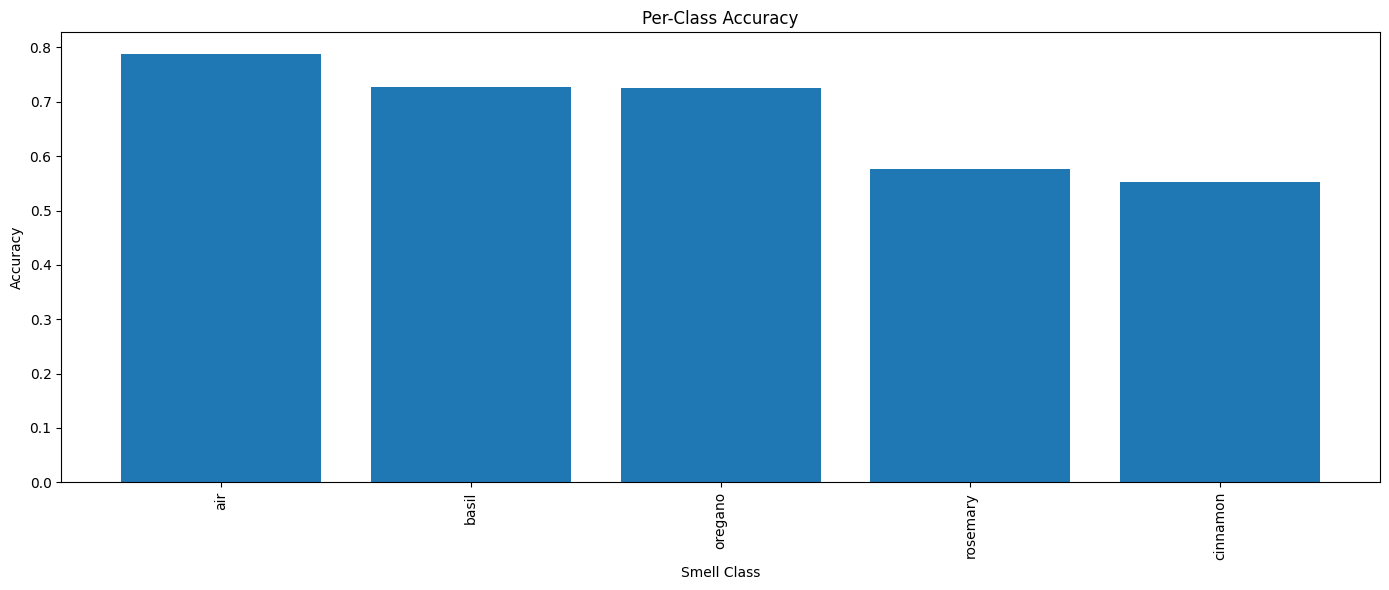

In [28]:
import matplotlib.pyplot as plt

sorted_idx = np.argsort(per_class_acc)[::-1]
sorted_acc = per_class_acc[sorted_idx]
sorted_names = class_names[sorted_idx]

plt.figure(figsize=(14,6))
plt.bar(sorted_names, sorted_acc)
plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.xlabel("Smell Class")
plt.title("Per-Class Accuracy")
plt.tight_layout()
plt.show()

## Convert to LiteRT model

In [18]:
import tensorflow as tf
import os

converter = tf.lite.TFLiteConverter.from_keras_model(model)
# Removed converter.optimizations = [tf.lite.Optimize.DEFAULT] to disable quantization for debugging

converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Apply the suggested fix for LSTM models
#converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
#converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

with open('model.tflite', 'wb') as f:
  f.write(tflite_model)

basic_model_size = os.path.getsize("model.tflite")
print("Model is %d bytes" % basic_model_size)


INFO:tensorflow:Assets written to: C:\Users\Benedek\AppData\Local\Temp\tmpxmt0x2oa\assets


INFO:tensorflow:Assets written to: C:\Users\Benedek\AppData\Local\Temp\tmpxmt0x2oa\assets


Saved artifact at 'C:\Users\Benedek\AppData\Local\Temp\tmpxmt0x2oa'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 8), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2676285444688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2676285446992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2676285446416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2676285446800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2676285446224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2676285446608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2676285447568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2676285447184: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model is 15296 bytes


In [20]:
from ai_edge_litert.compiled_model import CompiledModel
import numpy as np # Import numpy as it's used in the loop

model_lite = CompiledModel.from_file("model.tflite")

signature_index = 0

input_buffers = model_lite.create_input_buffers(signature_index)
output_buffers = model_lite.create_output_buffers(signature_index)

n_correct = 0

for i in range(len(X_test_seq)):
    input_data = np.float32(X_test_seq[i])
    input_buffers[0].write(input_data)

    model_lite.run_by_index(signature_index, input_buffers, output_buffers)
    output_array = output_buffers[0].read(NUM_CLASSES, np.float32)

    pred_class = int(np.argmax(output_array))
    true_class = int(y_test_seq[i])

    if pred_class == true_class:
        n_correct += 1

print("LiteRT accuracy:", n_correct / len(X_test_seq))


LiteRT accuracy: 0.9065972222222223
